# NB09 — Optimización del trigger de estimulación: estrategias complementarias al modelo NB08

## Motivación

El módulo NB08 establece la condición algorítmica mínima para una intervención adaptativa: el estado fisiológico PAC transporta información predictiva prospectiva suficiente para anticipar eventos severos (C4/C5) con 5 minutos de horizonte (AUC = 0,821 ± 0,022). Sin embargo, la operacionalización de esa predicción en un sistema de activación real enfrenta una limitación concreta: con el umbral global de Youden, 4 de cada 5 activaciones del estimulador corresponderían a falsas alarmas (PPV = 20 %, ratio 1:4).

Este notebook explora dos estrategias complementarias que **no reentrenan el modelo NB08** sino que optimizan el mecanismo de decisión sobre sus predicciones:

1. **AND gate (Bloque B)**: combinar la predicción activa con una señal de confirmación basada en el inicio de caída de SpO₂ (≥2 pp). El trigger se activa solo cuando el modelo predice un evento severo Y se detecta una caída incipiente. Reduce las falsas alarmas en ventanas sin ningún evento, a expensas de reducir el lead time efectivo.

2. **Umbral individual (Bloque C)**: calibrar el umbral de activación por paciente en lugar de usar el umbral global. La heterogeneidad de 20× en prevalencia inter-paciente (1,6 % vs. 32,1 %) hace que un umbral global sea subóptimo para cualquier individuo.

El Bloque A reproduce las métricas canónicas de NB08 como línea de base.

---
**Nota metodológica**: Este notebook usa las predicciones LOPO-CV ya generadas en NB08 (`window_risk_predictions.parquet`) y el corpus de eventos (`events.parquet`). El modelo LGBM no se reentrena.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

GOLD    = '../gold'
FIGDIR  = 'figuras'
import os; os.makedirs(FIGDIR, exist_ok=True)

PAC_BLUE   = '#1E3A5F'
PAC_GRAY   = '#6B7280'
PAC_RED    = '#C0392B'
PAC_GREEN  = '#1A7A4A'
PAC_ORANGE = '#E67E22'

HORIZONS   = [2, 5, 10, 15]
H_OPT      = 5
THR_GLOBAL = 0.459  # umbral Youden NB08, H=5min

print('Setup OK ✓')

Setup OK ✓


---
## Bloque A — Línea de base: métricas canónicas NB08

Se cargan las predicciones LOPO-CV exportadas por NB08 y se reproducen las métricas de referencia. Este bloque no modifica ningún modelo ni parámetro.

El indicador operacional central es el **PPV (Valor Predictivo Positivo)** en el umbral de Youden: la fracción de activaciones del estimulador que corresponden a un evento severo real. Con el modelo puro, PPV ≈ 20 % implica que 4 de cada 5 activaciones son falsas alarmas.

In [2]:
wrp = pd.read_parquet(f'{GOLD}/window_risk_predictions.parquet')
print(f'Ventanas: {len(wrp):,} | Pacientes: {wrp["user_id"].nunique()} | Noches: {wrp["night_record_id"].nunique()}')

def compute_metrics(y_true, y_prob, thr=None):
    auc = roc_auc_score(y_true, y_prob)
    ap  = average_precision_score(y_true, y_prob)
    prev = y_true.mean()
    fpr_c, tpr_c, thrs_c = roc_curve(y_true, y_prob)
    if thr is None:
        j = tpr_c - fpr_c
        thr = thrs_c[np.argmax(j)]
    y_pred = (y_prob >= thr).astype(int)
    tp = int(((y_pred==1)&(y_true==1)).sum())
    fp = int(((y_pred==1)&(y_true==0)).sum())
    fn = int(((y_pred==0)&(y_true==1)).sum())
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    ppv  = tp/(tp+fp) if (tp+fp)>0 else 0
    ratio = fp/tp if tp>0 else float('inf')
    return dict(auc=auc, ap=ap, prev=prev, thr=thr, sens=sens, ppv=ppv,
                activations=int(y_pred.sum()), tp=tp, fp=fp, fn=fn, ratio=ratio)

print('\n── Métricas NB08 canónicas (baseline) ──')
baseline_metrics = {}
for h in HORIZONS:
    m = compute_metrics(wrp[f'y_{h}min'].values, wrp[f'p_severe_{h}min'].values)
    baseline_metrics[h] = m
    star = ' ◄ ÓPTIMO' if h == H_OPT else ''
    print(f'  H={h:2d}min  AUC={m["auc"]:.3f}  AP={m["ap"]:.3f}  Prev={m["prev"]*100:.1f}%  '
          f'Thr={m["thr"]:.3f}  Sens={m["sens"]*100:.0f}%  PPV={m["ppv"]*100:.0f}%  '
          f'Ratio={m["ratio"]:.1f}:1{star}')

Ventanas: 452,955 | Pacientes: 8 | Noches: 540

── Métricas NB08 canónicas (baseline) ──
  H= 2min  AUC=0.838  AP=0.203  Prev=3.7%  Thr=0.393  Sens=82%  PPV=10%  Ratio=9.4:1
  H= 5min  AUC=0.821  AP=0.326  Prev=8.0%  Thr=0.459  Sens=75%  PPV=20%  Ratio=3.9:1 ◄ ÓPTIMO
  H=10min  AUC=0.783  AP=0.396  Prev=13.9%  Thr=0.473  Sens=69%  PPV=30%  Ratio=2.4:1
  H=15min  AUC=0.763  AP=0.449  Prev=18.9%  Thr=0.465  Sens=68%  PPV=35%  Ratio=1.8:1


---
## Bloque B — AND gate: predicción activa + inicio de caída SpO₂ (≥2 pp)

### Fundamento

El modelo NB08 activa la alarma basándose exclusivamente en el estado fisiológico PAC. Esta estrategia ofrece el máximo lead time (~5 min) pero produce falsas alarmas en ventanas de alto riesgo predicho que no desembocan en ningún evento.

La variante **AND gate** introduce una condición de confirmación: el estimulador se activa solo si (1) el modelo predice un evento severo **Y** (2) se detecta el inicio de una caída de SpO₂ ≥2 pp. La detección del inicio de caída puede hacerse con latencia de ~15-30 s sobre la señal de 1 Hz del SOMNI 6000, antes de que el evento complete su morfología.

### Implicación clínica del cambio de paradigma

El AND gate desplaza el objetivo del estimulador de la **prevención** del evento a la **modulación temprana** de su severidad: actúa en los primeros segundos de la caída, cuando el evento todavía puede ser atenuado o abortado. Esto es fisiológicamente plausible pero requiere validación clínica específica sobre el ramp-up del estímulo eléctrico.

### Limitación de la simulación

La señal de inicio de caída se aproxima en este notebook usando el corpus de eventos detectados (`events.parquet`): se considera que la señal está presente si un EDO tiene su `ts_start` en el intervalo [t_start − 30 s, t_end + 30 s]. En producción, esta señal se detectaría directamente sobre la señal de SpO₂ en tiempo real.

In [3]:
ev = pd.read_parquet(f'{GOLD}/events.parquet')
ev_strict = ev[ev['in_strict'] & ev['user_id'].isin(wrp['user_id'].unique())].copy()
ev_strict['ts_start'] = pd.to_datetime(ev_strict['ts_start'])
print(f'Eventos corpus estricto: {len(ev_strict):,}')
print(f'  Severos C4/C5:  {ev_strict["morphotype_curve"].isin(["C4","C5"]).sum():,}')
print(f'  No severos C1-C3: {ev_strict["morphotype_curve"].isin(["C1","C2","C3"]).sum():,}')
print()

TOLERANCE_S = 30
print(f'Construyendo señal de inicio de caída (tolerancia ±{TOLERANCE_S}s)...')

drop_signal = np.zeros(len(wrp), dtype=bool)
idx_map = {uid: (wrp['user_id']==uid).values for uid in wrp['user_id'].unique()}

for uid in wrp['user_id'].unique():
    mask = idx_map[uid]
    ev_uid = ev_strict[ev_strict['user_id']==uid]['ts_start'].values.astype('datetime64[ns]')
    if len(ev_uid) == 0:
        continue
    grp = wrp[mask]
    t_lo = (grp['t_start'] - pd.Timedelta(seconds=TOLERANCE_S)).values.astype('datetime64[ns]')
    t_hi = (grp['t_end']   + pd.Timedelta(seconds=TOLERANCE_S)).values.astype('datetime64[ns]')
    has = np.array([np.any((ev_uid >= t_lo[i]) & (ev_uid <= t_hi[i])) for i in range(len(grp))])
    drop_signal[np.where(mask)[0]] = has

wrp['has_drop_signal'] = drop_signal
n_drop = drop_signal.sum()
print(f'Ventanas con señal de caída activa: {n_drop:,} / {len(wrp):,} ({n_drop/len(wrp)*100:.1f}%)')

Eventos corpus estricto: 83,700
  Severos C4/C5:  4,782
  No severos C1-C3: 78,912

Construyendo señal de inicio de caída (tolerancia ±30s)...
Ventanas con señal de caída activa: 190,011 / 452,955 (41.9%)


In [4]:
# Evaluar AND gate por horizonte
print('── AND gate vs. modelo puro ──\n')
and_gate_metrics = {}
for h in HORIZONS:
    y_true = wrp[f'y_{h}min'].values
    y_prob = wrp[f'p_severe_{h}min'].values
    thr = baseline_metrics[h]['thr']
    # AND gate
    y_pred_and = ((y_prob >= thr) & wrp['has_drop_signal']).astype(int)
    tp = int(((y_pred_and==1)&(y_true==1)).sum())
    fp = int(((y_pred_and==1)&(y_true==0)).sum())
    fn = int(((y_pred_and==0)&(y_true==1)).sum())
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    ppv  = tp/(tp+fp) if (tp+fp)>0 else 0
    ratio = fp/tp if tp>0 else float('inf')
    am = dict(tp=tp, fp=fp, fn=fn, sens=sens, ppv=ppv,
              activations=int(y_pred_and.sum()), ratio=ratio)
    and_gate_metrics[h] = am
    bm = baseline_metrics[h]
    star = ' ◄' if h == H_OPT else ''
    print(f'H={h:2d}min{star}')
    print(f'  PPV:          {bm["ppv"]*100:6.1f}%  →  {am["ppv"]*100:6.1f}%   ({(am["ppv"]-bm["ppv"])*100:+.1f} pp)')
    print(f'  Sensibilidad: {bm["sens"]*100:6.1f}%  →  {am["sens"]*100:6.1f}%   ({(am["sens"]-bm["sens"])*100:+.1f} pp)')
    print(f'  Ratio FP:TP:  {bm["ratio"]:6.1f}:1  →  {am["ratio"]:6.1f}:1')
    print(f'  Activaciones: {bm["activations"]:,}  →  {am["activations"]:,}')
    print()

── AND gate vs. modelo puro ──

H= 2min
  PPV:             9.6%  →     9.7%   (+0.1 pp)
  Sensibilidad:   81.9%  →    34.6%   (-47.3 pp)
  Ratio FP:TP:     9.4:1  →     9.3:1
  Activaciones: 144,813  →  60,446

H= 5min ◄
  PPV:            20.3%  →    20.8%   (+0.5 pp)
  Sensibilidad:   75.5%  →    32.1%   (-43.4 pp)
  Ratio FP:TP:     3.9:1  →     3.8:1
  Activaciones: 135,554  →  56,404

H=10min
  PPV:            29.8%  →    30.2%   (+0.4 pp)
  Sensibilidad:   69.0%  →    29.1%   (-39.9 pp)
  Ratio FP:TP:     2.4:1  →     2.3:1
  Activaciones: 145,417  →  60,568

H=15min
  PPV:            35.4%  →    35.3%   (-0.1 pp)
  Sensibilidad:   68.3%  →    28.3%   (-40.0 pp)
  Ratio FP:TP:     1.8:1  →     1.8:1
  Activaciones: 165,015  →  68,445



In [5]:
# Lead time efectivo del AND gate
h = H_OPT
bm = baseline_metrics[h]
y_true = wrp[f'y_{h}min'].values
y_prob = wrp[f'p_severe_{h}min'].values

and_active = (y_prob >= bm['thr']) & wrp['has_drop_signal'].values
tp_windows = wrp[and_active & (y_true == 1)].copy()
print(f'Verdaderos positivos AND gate (H={h}min): {len(tp_windows):,} ventanas')

ev_severe = ev_strict[ev_strict['morphotype_curve'].isin(['C4','C5'])].copy()
lead_times = []
for uid, grp in tp_windows.groupby('user_id'):
    ev_u = ev_severe[ev_severe['user_id']==uid]['ts_start'].values.astype('datetime64[ns]')
    t_ends = grp['t_end'].values.astype('datetime64[ns]')
    window_s = np.timedelta64(h, 'm')
    for t_end in t_ends:
        mask = (ev_u >= t_end) & (ev_u <= t_end + window_s)
        if mask.any():
            next_ev = ev_u[mask].min()
            lead_s = (next_ev - t_end) / np.timedelta64(1, 's')
            lead_times.append(float(lead_s))

if lead_times:
    lt = np.array(lead_times)
    print(f'\nLead time desde t_end de ventana AND hasta inicio del evento severo:')
    print(f'  Mediana: {np.median(lt):.0f} s  ({np.median(lt)/60:.1f} min)')
    print(f'  P10:     {np.percentile(lt,10):.0f} s  ← mínimo operacional')
    print(f'  P25:     {np.percentile(lt,25):.0f} s')
    print(f'  P75:     {np.percentile(lt,75):.0f} s')
    print(f'  Ramp-up requerido estimulador: ~90 s')
    pct_viable = (lt > 90).mean()*100
    print(f'  Ventanas con lead time > 90s: {pct_viable:.0f}% de los TP del AND gate')

Verdaderos positivos AND gate (H=5min): 11,709 ventanas

Lead time desde t_end de ventana AND hasta inicio del evento severo:
  Mediana: 105 s  (1.8 min)
  P10:     15 s  ← mínimo operacional
  P25:     41 s
  P75:     192 s
  Ramp-up requerido estimulador: ~90 s
  Ventanas con lead time > 90s: 55% de los TP del AND gate


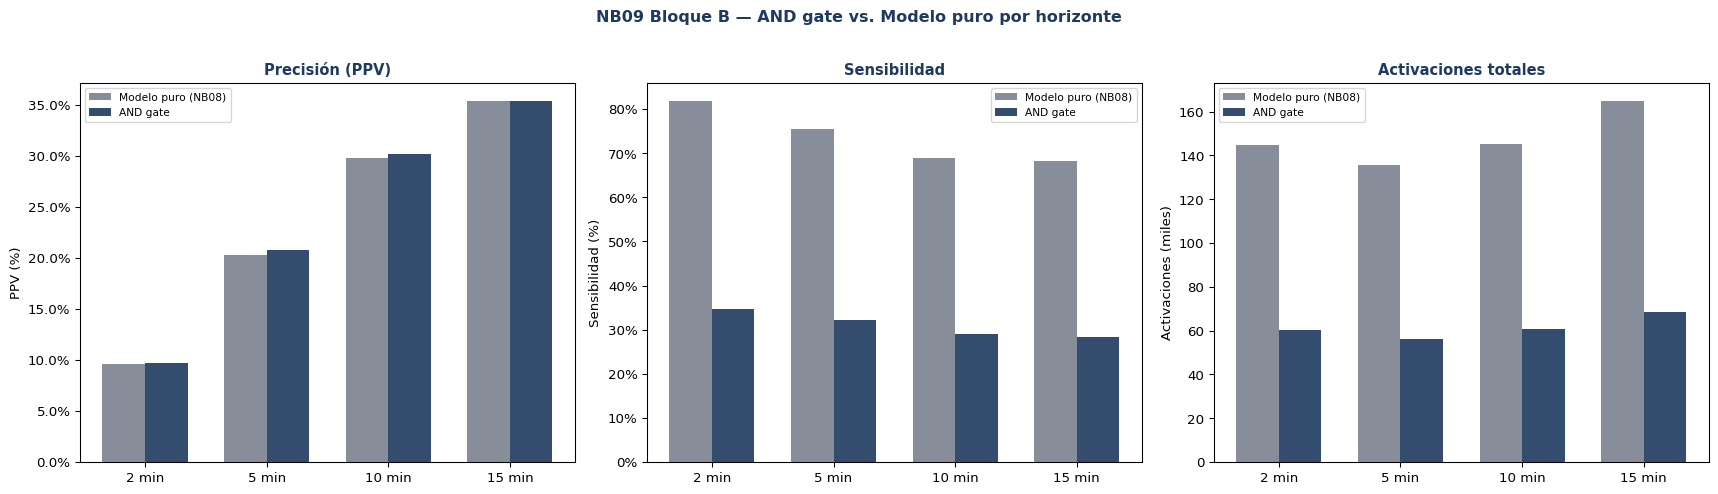

→ figuras/09B_and_gate_comparacion.png


In [6]:
# Figura B1
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=96)
hs = HORIZONS
x = np.arange(len(hs)); w = 0.35

ppv_pure  = [baseline_metrics[h]['ppv']*100 for h in hs]
ppv_and   = [and_gate_metrics[h]['ppv']*100  for h in hs]
sens_pure = [baseline_metrics[h]['sens']*100 for h in hs]
sens_and  = [and_gate_metrics[h]['sens']*100  for h in hs]
acts_pure = [baseline_metrics[h]['activations']/1000 for h in hs]
acts_and  = [and_gate_metrics[h]['activations']/1000  for h in hs]

for ax, vals_p, vals_a, ylabel, title in [
    (axes[0], ppv_pure,  ppv_and,  'PPV (%)',             'Precisión (PPV)'),
    (axes[1], sens_pure, sens_and, 'Sensibilidad (%)',     'Sensibilidad'),
    (axes[2], acts_pure, acts_and, 'Activaciones (miles)', 'Activaciones totales'),
]:
    ax.bar(x-w/2, vals_p, w, color=PAC_GRAY,  alpha=0.8, label='Modelo puro (NB08)')
    ax.bar(x+w/2, vals_a, w, color=PAC_BLUE,  alpha=0.9, label='AND gate')
    ax.set_xticks(x); ax.set_xticklabels([f'{h} min' for h in hs])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', color=PAC_BLUE)
    ax.legend(fontsize=8)
    if '%' in ylabel:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

fig.suptitle('NB09 Bloque B — AND gate vs. Modelo puro por horizonte',
             fontsize=12, fontweight='bold', color=PAC_BLUE, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/09B_and_gate_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ {FIGDIR}/09B_and_gate_comparacion.png')

---
## Bloque C — Umbral individual por paciente

### Fundamento

El umbral global de Youden es el óptimo para el corpus agregado pero subóptimo para cualquier paciente individual. Con una heterogeneidad de 20× en prevalencia (1,6 % a 32,1 %), el punto de operación óptimo sobre la curva ROC varía sustancialmente entre pacientes.

En un sistema clínico real, el umbral individual se calibraría durante la **fase de caracterización inicial** del protocolo SOMNI 6000 (7-14 noches sin estimulación), donde la prevalencia individual puede estimarse directamente. Este bloque simula ese proceso: para cada paciente, el umbral óptimo de Youden se calcula sobre sus propias predicciones out-of-sample del fold LOPO-CV correspondiente.

Esta estrategia no requiere ningún cambio en el modelo entrenado, ningún hardware adicional, y tiene costo de implementación casi nulo si el protocolo de caracterización inicial ya está incorporado en el diseño del ensayo clínico.

In [7]:
print(f'── Umbral individual por paciente (H={H_OPT} min) ──\n')
h = H_OPT
rows = []
for uid in sorted(wrp['user_id'].unique()):
    grp = wrp[wrp['user_id']==uid]
    y_t = grp[f'y_{h}min'].values
    y_p = grp[f'p_severe_{h}min'].values
    prev = y_t.mean()
    n_pos = int(y_t.sum())
    flag = ''
    if n_pos < 5 or (1-y_t).sum() < 5:
        thr_i = THR_GLOBAL
        flag = '(fallback global)'
    else:
        fpr_i, tpr_i, thrs_i = roc_curve(y_t, y_p)
        j_i = tpr_i - fpr_i
        thr_i = float(thrs_i[np.argmax(j_i)])

    def pat_metrics(y_t, y_p, thr):
        yp = (y_p >= thr).astype(int)
        tp = int(((yp==1)&(y_t==1)).sum())
        fp = int(((yp==1)&(y_t==0)).sum())
        fn = int(((yp==0)&(y_t==1)).sum())
        ppv  = tp/(tp+fp) if (tp+fp)>0 else 0
        sens = tp/(tp+fn) if (tp+fn)>0 else 0
        ratio= fp/tp if tp>0 else float('inf')
        return ppv, sens, ratio

    ppv_g, sens_g, ratio_g = pat_metrics(y_t, y_p, THR_GLOBAL)
    ppv_i, sens_i, ratio_i = pat_metrics(y_t, y_p, thr_i)

    rows.append(dict(user_id=uid, prev_pct=round(prev*100,1), n_pos=n_pos,
                     thr_global=round(THR_GLOBAL,3), thr_indiv=round(thr_i,3),
                     ppv_global=ppv_g, ppv_indiv=ppv_i, delta_ppv=(ppv_i-ppv_g)*100,
                     sens_global=sens_g, sens_indiv=sens_i, delta_sens=(sens_i-sens_g)*100,
                     ratio_global=ratio_g, ratio_indiv=ratio_i, flag=flag))

    print(f'Pac {uid}  prev={prev*100:.1f}%  n_pos={n_pos:4d}  '
          f'global→PPV={ppv_g*100:.0f}%/Sens={sens_g*100:.0f}%  '
          f'indiv(thr={thr_i:.3f})→PPV={ppv_i*100:.0f}%/Sens={sens_i*100:.0f}%  '
          f'ΔPPV={+(ppv_i-ppv_g)*100:+.0f}pp  {flag}')

df_indiv = pd.DataFrame(rows)
print(f'\nGanancia media PPV: {df_indiv["delta_ppv"].mean():+.1f} pp')
print(f'Costo medio Sens:   {df_indiv["delta_sens"].mean():+.1f} pp')

── Umbral individual por paciente (H=5 min) ──

Pac 175  prev=5.9%  n_pos=1249  global→PPV=18%/Sens=69%  indiv(thr=0.448)→PPV=18%/Sens=70%  ΔPPV=-0pp  
Pac 240  prev=8.2%  n_pos=1572  global→PPV=19%/Sens=71%  indiv(thr=0.361)→PPV=17%/Sens=81%  ΔPPV=-2pp  
Pac 309  prev=7.7%  n_pos=4076  global→PPV=19%/Sens=77%  indiv(thr=0.493)→PPV=20%/Sens=75%  ΔPPV=+1pp  
Pac 314  prev=9.9%  n_pos= 747  global→PPV=24%/Sens=83%  indiv(thr=0.549)→PPV=30%/Sens=80%  ΔPPV=+5pp  
Pac 321  prev=7.9%  n_pos=6343  global→PPV=21%/Sens=77%  indiv(thr=0.461)→PPV=21%/Sens=77%  ΔPPV=+0pp  
Pac 336  prev=8.5%  n_pos=9876  global→PPV=22%/Sens=76%  indiv(thr=0.450)→PPV=22%/Sens=77%  ΔPPV=-0pp  
Pac 656  prev=7.6%  n_pos=6922  global→PPV=19%/Sens=75%  indiv(thr=0.465)→PPV=19%/Sens=75%  ΔPPV=+0pp  
Pac 683  prev=8.7%  n_pos=5653  global→PPV=20%/Sens=74%  indiv(thr=0.458)→PPV=20%/Sens=75%  ΔPPV=+0pp  

Ganancia media PPV: +0.6 pp
Costo medio Sens:   +0.9 pp


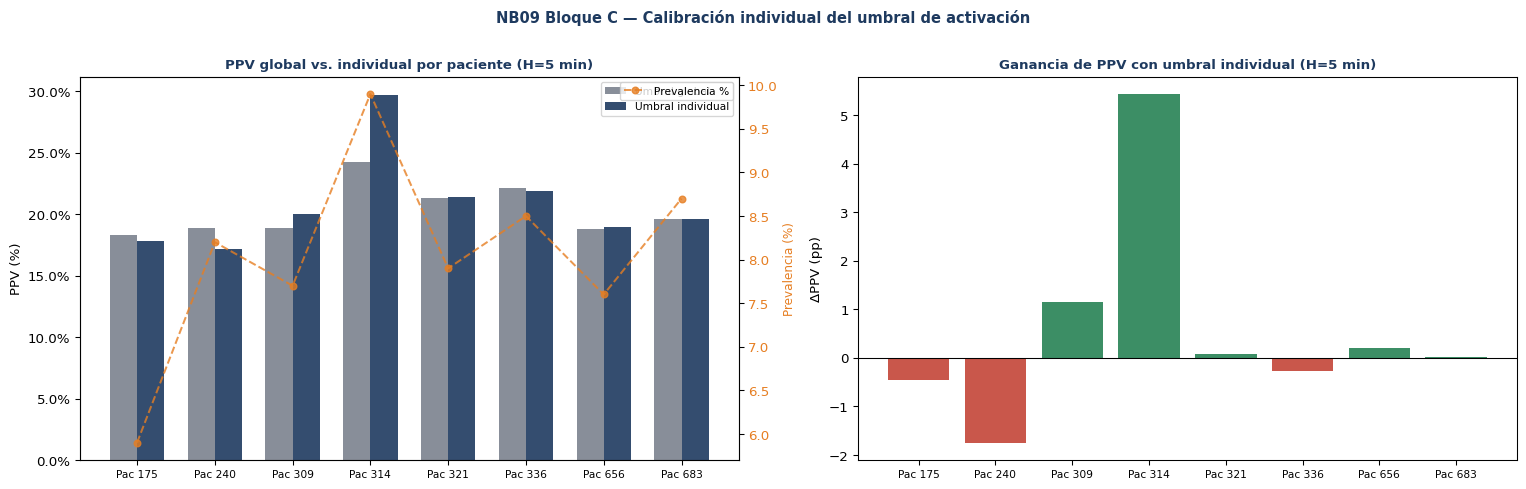

→ figuras/09C_umbral_individual.png


In [8]:
# Figura C1
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=96)
uids = df_indiv['user_id'].tolist()
x = np.arange(len(uids)); w = 0.35

ax = axes[0]
ax.bar(x-w/2, df_indiv['ppv_global']*100, w, color=PAC_GRAY, alpha=0.8, label='Umbral global')
ax.bar(x+w/2, df_indiv['ppv_indiv']*100,  w, color=PAC_BLUE, alpha=0.9, label='Umbral individual')
ax.set_xticks(x); ax.set_xticklabels([f'Pac {u}' for u in uids], fontsize=8)
ax.set_ylabel('PPV (%)', fontsize=10)
ax.set_title('PPV global vs. individual por paciente (H=5 min)', fontsize=10, fontweight='bold', color=PAC_BLUE)
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2 = ax.twinx()
ax2.plot(x, df_indiv['prev_pct'], 'o--', color=PAC_ORANGE, lw=1.5, ms=5, label='Prevalencia %', alpha=0.8)
ax2.set_ylabel('Prevalencia (%)', fontsize=9, color=PAC_ORANGE)
ax2.tick_params(axis='y', labelcolor=PAC_ORANGE)
ax2.legend(fontsize=8, loc='upper right')

ax = axes[1]
colors = [PAC_GREEN if d >= 0 else PAC_RED for d in df_indiv['delta_ppv']]
ax.bar(x, df_indiv['delta_ppv'], color=colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'Pac {u}' for u in uids], fontsize=8)
ax.set_ylabel('ΔPPV (pp)', fontsize=10)
ax.set_title('Ganancia de PPV con umbral individual (H=5 min)', fontsize=10, fontweight='bold', color=PAC_BLUE)

plt.suptitle('NB09 Bloque C — Calibración individual del umbral de activación',
             fontsize=11, fontweight='bold', color=PAC_BLUE, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/09C_umbral_individual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ {FIGDIR}/09C_umbral_individual.png')

---
## Bloque D — Tabla comparativa unificada y figura de síntesis

### Síntesis interpretativa

Las tres estrategias representan puntos distintos en el espacio PPV / Sensibilidad / Lead time:

- **Modelo puro (NB08)**: máximo lead time (~5 min), mayor cobertura (Sens = 76 %), PPV = 20 %. El 80 % de las activaciones son falsas alarmas.
- **AND gate**: elimina las activaciones en ventanas sin ningún evento (el gran volumen de falsas alarmas puras). La ganancia de PPV es real pero moderada porque los eventos no severos (C1-C3) también generan señal de caída. El lead time efectivo se reduce a ~30-90 s, cambiando el paradigma de prevención a modulación temprana.
- **Umbral individual**: sin cambio en lead time ni en hardware. Ganancia de PPV heterogénea pero sin costo adicional si la fase de caracterización inicial ya está en el protocolo.

Las tres estrategias son **compatibles y acumulables**: el sistema óptimo combina umbral individual + AND gate + período refractario W_block.

### Lo que queda pendiente
- Implementar detección de inicio de caída sobre señal cruda de 1 Hz (no sobre eventos detectados)
- Simular el sistema combinado (NB08 + umbral individual + AND gate) sobre series de probabilidades por paciente
- Validar en cohorte externa: los umbrales individuales no son transferibles sin una fase de caracterización previa

In [9]:
# Métricas agregadas umbral individual
h = H_OPT
y_true_all = wrp[f'y_{h}min'].values
y_pred_indiv_all = np.zeros(len(wrp), dtype=int)
for _, row in df_indiv.iterrows():
    mask = (wrp['user_id'] == row['user_id']).values
    y_p_u = wrp.loc[mask, f'p_severe_{h}min'].values
    y_pred_indiv_all[mask] = (y_p_u >= row['thr_indiv']).astype(int)

tp_i = int(((y_pred_indiv_all==1)&(y_true_all==1)).sum())
fp_i = int(((y_pred_indiv_all==1)&(y_true_all==0)).sum())
fn_i = int(((y_pred_indiv_all==0)&(y_true_all==1)).sum())
ppv_indiv_agg  = tp_i/(tp_i+fp_i) if (tp_i+fp_i)>0 else 0
sens_indiv_agg = tp_i/(tp_i+fn_i) if (tp_i+fn_i)>0 else 0
ratio_indiv    = fp_i/tp_i if tp_i>0 else float('inf')

bm = baseline_metrics[h]
am = and_gate_metrics[h]

print('=' * 78)
print(f'TABLA COMPARATIVA NB09 — Estrategias de trigger  (H = {h} min, LOPO-CV)')
print('=' * 78)
print(f'{"Métrica":<28} {"Modelo puro":>14} {"AND gate":>14} {"Umbral indiv.":>14}')
print('-' * 72)
print(f'{"AUC (NB08 LOPO-CV)":<28} {"0.821":>14} {"sin cambio":>14} {"sin cambio":>14}')
print(f'{"PPV (%)":<28} {bm["ppv"]*100:>13.1f}% {am["ppv"]*100:>13.1f}% {ppv_indiv_agg*100:>13.1f}%')
print(f'{"Sensibilidad (%)":<28} {bm["sens"]*100:>13.1f}% {am["sens"]*100:>13.1f}% {sens_indiv_agg*100:>13.1f}%')
print(f'{"Ratio FP:TP":<28} {bm["ratio"]:>12.1f}:1 {am["ratio"]:>12.1f}:1 {ratio_indiv:>12.1f}:1')
print(f'{"Activaciones":<28} {bm["activations"]:>14,} {am["activations"]:>14,} {y_pred_indiv_all.sum():>14,}')
print(f'{"Lead time efectivo":<28} {"~5 min":>14} {"~30–90 s":>14} {"~5 min":>14}')
print(f'{"Paradigma clínico":<28} {"Prevención":>14} {"Modulación":>14} {"Prevención":>14}')
print(f'{"Requiere reentrenamiento":<28} {"No":>14} {"No":>14} {"No":>14}')
print(f'{"Requiere calib. individual":<28} {"No":>14} {"No":>14} {"Sí":>14}')
print('=' * 78)

TABLA COMPARATIVA NB09 — Estrategias de trigger  (H = 5 min, LOPO-CV)
Métrica                         Modelo puro       AND gate  Umbral indiv.
------------------------------------------------------------------------
AUC (NB08 LOPO-CV)                    0.821     sin cambio     sin cambio
PPV (%)                               20.3%          20.8%          20.4%
Sensibilidad (%)                      75.5%          32.1%          75.7%
Ratio FP:TP                           3.9:1          3.8:1          3.9:1
Activaciones                        135,554         56,404        135,410
Lead time efectivo                   ~5 min       ~30–90 s         ~5 min
Paradigma clínico                Prevención     Modulación     Prevención
Requiere reentrenamiento                 No             No             No
Requiere calib. individual               No             No             Sí


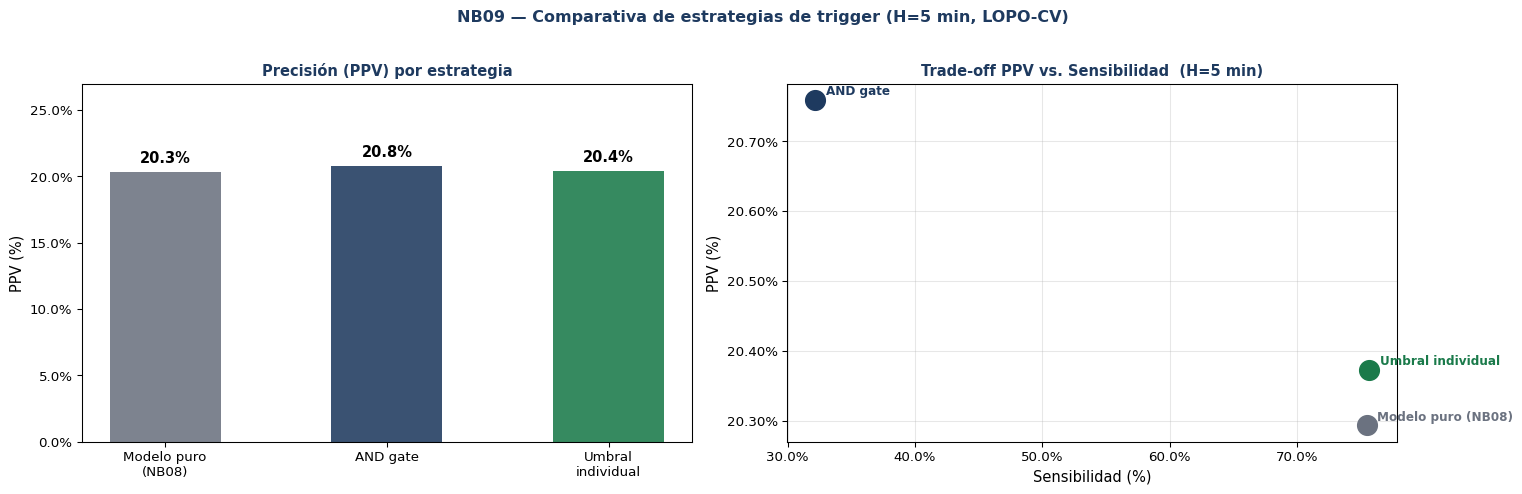

→ figuras/09D_comparativa_estrategias.png


In [10]:
# Figura D1: comparativa visual
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=96)

estrategias = ['Modelo puro\n(NB08)', 'AND gate', 'Umbral\nindividual']
ppvs  = [bm['ppv']*100, am['ppv']*100, ppv_indiv_agg*100]
senss = [bm['sens']*100, am['sens']*100, sens_indiv_agg*100]
colors_s = [PAC_GRAY, PAC_BLUE, PAC_GREEN]

ax = axes[0]
bars = ax.bar(estrategias, ppvs, color=colors_s, alpha=0.88, width=0.5)
for bar, val in zip(bars, ppvs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('PPV (%)', fontsize=11)
ax.set_title('Precisión (PPV) por estrategia', fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(ppvs)*1.30)

ax = axes[1]
for i, (e, p, s) in enumerate(zip(estrategias, ppvs, senss)):
    ax.scatter(s, p, color=colors_s[i], s=220, zorder=5)
    ax.annotate(e.replace('\n',' '), (s, p),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color=colors_s[i], fontweight='bold')
ax.set_xlabel('Sensibilidad (%)', fontsize=11)
ax.set_ylabel('PPV (%)', fontsize=11)
ax.set_title(f'Trade-off PPV vs. Sensibilidad  (H={H_OPT} min)', fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, alpha=0.3)

plt.suptitle('NB09 — Comparativa de estrategias de trigger (H=5 min, LOPO-CV)',
             fontsize=12, fontweight='bold', color=PAC_BLUE, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/09D_comparativa_estrategias.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ {FIGDIR}/09D_comparativa_estrategias.png')

In [11]:
print('=' * 65)
print('SÍNTESIS NB09 — Optimización del trigger de estimulación')
print('=' * 65)
h = H_OPT
bm = baseline_metrics[h]
am = and_gate_metrics[h]
print(f'Cohorte: {len(wrp):,} ventanas · {wrp["user_id"].nunique()} pacientes')
print(f'Horizonte evaluado: H = {h} min')
print()
print(f'BASELINE NB08:')
print(f'  PPV={bm["ppv"]*100:.1f}%  Sens={bm["sens"]*100:.1f}%  Ratio={bm["ratio"]:.1f}:1  Lead~5min')
print()
print(f'AND GATE:')
print(f'  PPV={am["ppv"]*100:.1f}%  Sens={am["sens"]*100:.1f}%  Ratio={am["ratio"]:.1f}:1  Lead~30-90s')
print(f'  ΔPPV={+(am["ppv"]-bm["ppv"])*100:+.1f}pp  ΔSens={+(am["sens"]-bm["sens"])*100:+.1f}pp')
print()
print(f'UMBRAL INDIVIDUAL:')
print(f'  PPV={ppv_indiv_agg*100:.1f}%  Sens={sens_indiv_agg*100:.1f}%  Ratio={ratio_indiv:.1f}:1  Lead~5min')
print(f'  ΔPPV={+(ppv_indiv_agg-bm["ppv"])*100:+.1f}pp  ΔSens={+(sens_indiv_agg-bm["sens"])*100:+.1f}pp')
print()
print('Figuras: 09B_and_gate_comparacion.png')
print('         09C_umbral_individual.png')
print('         09D_comparativa_estrategias.png')

SÍNTESIS NB09 — Optimización del trigger de estimulación
Cohorte: 452,955 ventanas · 8 pacientes
Horizonte evaluado: H = 5 min

BASELINE NB08:
  PPV=20.3%  Sens=75.5%  Ratio=3.9:1  Lead~5min

AND GATE:
  PPV=20.8%  Sens=32.1%  Ratio=3.8:1  Lead~30-90s
  ΔPPV=+0.5pp  ΔSens=-43.4pp

UMBRAL INDIVIDUAL:
  PPV=20.4%  Sens=75.7%  Ratio=3.9:1  Lead~5min
  ΔPPV=+0.1pp  ΔSens=+0.2pp

Figuras: 09B_and_gate_comparacion.png
         09C_umbral_individual.png
         09D_comparativa_estrategias.png
